# Lesson 01b: Group Representations

**What you will learn**

- What a group **representation** is and why the homomorphism property, $D(g_1 g_2) = D(g_1)\,D(g_2)$, is exactly what a network layer needs to know about its data.
- What **Reducible** and **irreducible** representations are and how a $3\times 3$ tensor decomposes.
- The irreducible representations (**irreps**) of $SO(3)$, which are labeled by $l = 0, 1, 2, \dots$ with dimension $2l+1$. Their matrix representations are the **Wigner D-matrices** (`o3.wigner_D`).
- Numerical verification of the homomorphism property and the **Schur orthogonality** relations
- The visualization of the **block-diagonal** structure of a reducible representation
- **Parity**, the $O(3) = SO(3) \times \{\mathbb{1}, P\}$ group, and why a Cartesian 3-vector is its irrep $(l{=}1,\ \text{odd})$

**Prerequisites:**

- [Lesson 01a](01a_symmetry_and_equivariance.ipynb) and/or
- Basic knowledge of groups: $SO(3) \subset O(3) \subset E(3)$
- The definition of equivariance

In [1]:
import sys
sys.path.insert(0, "..")  # Make course_utils importable

import matplotlib.pyplot as plt
import numpy as np
import torch
import e3nn
from e3nn import o3

torch.set_default_dtype(torch.float64)  # float64 so representation identities hold to ~1e-15
torch.manual_seed(0)
np.random.seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"torch {torch.__version__} | device: {device}")
print(f"e3nn {e3nn.__version__}")

torch 2.7.1+cu126 | device: cuda
e3nn 0.6.0


## What is a representation?

In Lesson 01a the definition of equivariance, $f(D_X(g)x) = D_Y(g)f(x)$, used $D(g)$ matrices that describe "how the data transforms". Those matrices cannot be arbitrary: they must compose the way the group does. Quoting [Geiger & Smidt, *e3nn: Euclidean Neural Networks* arXiv.2207.09453 (2021)](https://arxiv.org/pdf/2207.09453):

> For a given group $G$, a function $D: G \to \mathbb{R}^{d \times d}$ that maps each
> element of the group to a $d \times d$ matrix is a **representation** iff it follows
> the structure of the group: 
> $$
> D(e) = \mathbb{1}, \qquad \text{and} \qquad D(g_1 g_2) = D(g_1)\, D(g_2) \qquad \forall\, g_1, g_2 \in G.
> $$

The vector space $\mathbb{R}^d$ the matrices act on is the *carrier space*: it is where our data (features) live. Three representations of $SO(3)$ we already know:

1. the **trivial** representation, $D(R) = 1$ on $\mathbb{R}^1$ — scalars;
2. the **vector** representation, $D(R) = R$ on $\mathbb{R}^3$ — positions, forces;
3. the **tensor** representation, $D(R) = R \otimes R$ on $\mathbb{R}^9$ where $x \mapsto R\,x\,R^\top$ and $\otimes$ denotes the Kronecker producton.

In the third case, flattening $x$ to $\mathrm{vec}(x) \in \mathbb{R}^9$ and transforming it with $D(R)$, i.e., $D(R)\,\mathrm{vec}(x)$ is equivalent to $\mathrm{vec}(R\,x\,R^\top)$. Let's verify this numerically.

In [2]:
# Verify the homomorphism property D(g1 g2) = D(g1) D(g2) for the 9-dim tensor rep
R1, R2 = o3.rand_matrix(), o3.rand_matrix()

# The tensor representation is D(R) = R kron R, where kron is the Kronecker product
D = lambda R: torch.kron(R, R)

# Verify the homomorphism property D(R1 R2) = D(R1) D(R2)
hom_err = (D(R1 @ R2) - D(R1) @ D(R2)).abs().max()
print(f"tensor rep  (d=9):  |D(R1 R2) - D(R1) D(R2)| = {hom_err:.2e}")

# ... and, trivially, for the vector rep D(R) = R (the homomorphism is R1 @ R2 itself)
x = torch.randn(3, 3)                       # a rank-2 tensor, transformed in two ways:
lhs = (D(R1) @ x.flatten()).reshape(3, 3)   # via flattening x and the 9 x 9 matrix D(R1)
rhs = R1 @ x @ R1.T                         # or via the 3 x 3 matrix R1 and the original x (3, 3)
print(f"|vec(R x R^T) - (R kron R) vec(x)|           = {(lhs - rhs).abs().max():.2e}")

tensor rep  (d=9):  |D(R1 R2) - D(R1) D(R2)| = 1.67e-16
|vec(R x R^T) - (R kron R) vec(x)|           = 2.78e-16


## Reducible vs. irreducible representations

The 9-dimensional tensor representation is *wasteful* because it contains and can be reduced to smaller representations. [Geiger & Smidt, *e3nn: Euclidean Neural Networks* arXiv.2207.09453 (2021)](https://arxiv.org/pdf/2207.09453) mentions:

> An **irreducible representation** (irrep) is a representation that does not contain a
> smaller representation in it.

So, what does "contains" mean in the present context? It means there is a subspace in the current 9-dimentional tensor representation that transforms only within itself and among its members. For a $3\times 3$ tensor $x$ under the transformation $x \mapsto RxR^\top$:

- the **trace** $\mathrm{Tr}(x)$ is a single number that never mixes with the remaining elements of the tensor: the trace, therefore, creates a 1-dimensional invariant subspace (a scalar, $l = 0$);
- the **antisymmetric part** $\tfrac{1}{2}(x - x^\top)$ has 3 independent components that mix only among themselves ($l = 1$; it is equivalent to a vector via $a_k = \tfrac{1}{2}\epsilon_{ijk} x_{ij}$);
- the **symmetric traceless part** has $5$ components that mix only among themselves ($l = 2$).

So, $9 = 1 + 3 + 5$: the tensor representation is **reducible**, and in the right basis, its matrix representation becomes **block-diagonal** with $l=0$, $1$ and $2$ blocks. As such, it should not be surprising to see that the irreps of groups such as $SO(3)$ are indexed by $l = 0, 1, 2, \dots$. Each irrep, labeled by $l$ has a dimension of $2l + 1$. The **Wigner D-matrices**, $D^{(l)}(g) \in \mathbb{R}^{(2l+1) \times (2l+1)}$, are the representation matrices of the $l$-irreps.

<div style="background: rgba(33, 150, 243, 0.10); border-left: 4px solid #2196f3; padding: 0.6em 1em; margin: 0.8em 0; border-radius: 0 4px 4px 0;"> 

<b>Note:</b> The Wigner D-matrices are unitary matrices. However, The e3nn works in a real basis, so the representation matrices of the $l$-irreps (or Wigner D-matrices) become real orthogonal matrices. 
</div>

Every finite-dimensional representation of $SO(3)$ decomposes into a direct sum of irreps. As such, irreps are the "prime numbers" of representation theory, and they will be the native *data types* of every network in this course.

Let's check out the Wigner D-matrices for various $l$ values and verify their dimensions. First, we need to create a random rotation matrix $R$ and convert it to Euler angles, $(\alpha, \beta, \gamma)$ to compute the Wigner D-matrices. You can use e3nn's `o3.wigner_D(l, alpha, beta, gamma)` to calculate the Wigner D-matrix with Euler angles.

In [3]:
# A rotation matrix R is converted to angles with o3.matrix_to_angles(R).
R = o3.rand_matrix()

# D^(l)(R): the l-irrep matrix of the rotation R
def D_l(l, R):                       
    return o3.wigner_D(l, *o3.matrix_to_angles(R))

# Create a random rotation matrix R and compute the Wigner D-matrices for l = 0, 1, 2, 3
for l in range(4):
    Dl = D_l(l, R)
    print(f"l = {l}:  D^(l) shape {tuple(Dl.shape)}   (dimension 2l+1 = {2*l+1})")

l = 0:  D^(l) shape (1, 1)   (dimension 2l+1 = 1)
l = 1:  D^(l) shape (3, 3)   (dimension 2l+1 = 3)
l = 2:  D^(l) shape (5, 5)   (dimension 2l+1 = 5)
l = 3:  D^(l) shape (7, 7)   (dimension 2l+1 = 7)


Having calculated the Wigner D-matrices, we can check their homomorphism property, expressed by

$$ D(g_1 g_2) = D(g_1)\, D(g_2) $$

as well as their unitarity (orthogonality in the real basis), expressed by

$$ D(g)^\top D(g) = \mathbb{1}. $$

In [4]:
# Numerical checks, for each l: homomorphism, orthogonality, identity

# Create two random rotation matrices R1 and R2, and the identity matrix I3
R1, R2, I3 = o3.rand_matrix(), o3.rand_matrix(), torch.eye(3)

# Print the header for the numerical checks
print(f"{'l':>2} {'|D(R1 R2)-D(R1)D(R2)|':>22} {'|D^T D - 1|':>14} {'|D(1)-1|':>10}")

# Perform the numerical checks for l = 0, 1, 2, 3
for l in range(4):
    # Compute the maximum absolute errors for homomorphism, orthogonality, and identity
    hom  = (D_l(l, R1 @ R2) - D_l(l, R1) @ D_l(l, R2)).abs().max()
    
    # Here, l=l' and R1 is a rotation matrix, so D_l(l, R1) should be orthogonal: D^T D = 1
    orth = (D_l(l, R1).T @ D_l(l, R1) - torch.eye(2 * l + 1)).abs().max()
    idn  = (D_l(l, I3) - torch.eye(2 * l + 1)).abs().max()
    print(f"{l:>2} {hom:>22.2e} {orth:>14.2e} {idn:>10.2e}")

 l  |D(R1 R2)-D(R1)D(R2)|    |D^T D - 1|   |D(1)-1|
 0               0.00e+00       0.00e+00   0.00e+00
 1               1.11e-15       1.78e-15   0.00e+00
 2               4.00e-15       4.66e-15   0.00e+00
 3               1.20e-14       6.88e-15   0.00e+00


All identities hold to float64 round-off: each $D^{(l)}$ is a genuine representation (homomorphism + identity), and its matrices are orthogonal, $D^{(l)}(R)^\top D^{(l)}(R) = \mathbb{1}$: rotating features never changes their norm. This is why deep equivariant networks don't suffer from features blowing up under rotation.

### Schur orthogonality: different irreps are perpendicular functions

According to the classical **Schur orthogonality relation**, applied to the Wigner D-matrices and $SO(3)$ group,

$$ \int_{SO(3)} D^{(l)}_{ij}(g)\, D^{(l')}_{kl}(g)\; d\mu(g) \;=\; \frac{1}{2l + 1} \delta_{ll'}\,\delta_{ik}\,\delta_{jl}, $$

the irreps of $SO(3)$ are orthogonal to each other. Here, $d\mu(g)$ is the (normalized) **Haar measure**: the unique rotation-invariant way to average over the group, which is exactly what `o3.rand_matrix` samples from.

Let us verify the Schur orthogonality by Monte Carlo. Here, we assume $\mu \approx g$ and average the products of Wigner-D entries over many random rotations.

same irrep  (l=1,l=1): max |gram - I/3| = 5.2e-03   (Monte-Carlo error ~ 1/sqrt(n) = 7.1e-03)
cross irrep (l=1,l=2): max |gram|       = 5.1e-03


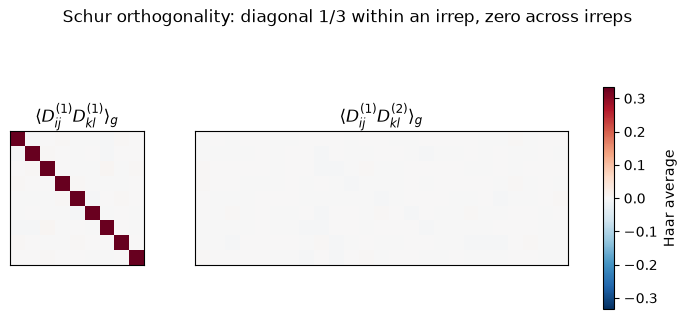

In [5]:
# Set the number of random rotations to sample for the Monte Carlo verification
# of Schur orthogonality
n = 20_000

# Haar-random rotations, batched
angles = o3.matrix_to_angles(o3.rand_matrix(n))

# rows: vec of D^(1)(g)
D1 = o3.wigner_D(1, *angles).reshape(n, 9)
D2 = o3.wigner_D(2, *angles).reshape(n, 25)

# For l=l'=1, (2l+1, 2l'+1) = (9, 9)
# expect  1/(2l+1) * identity = I/3
gram_11 = D1.T @ D1 / n

# For l=1, l'=2, (2l+1, 2l'+1) = (9, 25)
# expect  0 (different irreps)
gram_12 = D1.T @ D2 / n

# Print the maximum absolute errors for the same irrep (l=1,l=1) and cross irrep (l=1,l=2)
print(f"same irrep  (l=1,l=1): max |gram - I/3| = {(gram_11 - torch.eye(9)/3).abs().max():.1e}"
      f"   (Monte-Carlo error ~ 1/sqrt(n) = {n ** -0.5:.1e})")
print(f"cross irrep (l=1,l=2): max |gram|       = {gram_12.abs().max():.1e}")

# Plot the Gram matrices for the same irrep (l=1,l=1) and cross irrep (l=1,l=2)
fig, axes = plt.subplots(1, 2, figsize=(9, 3.6), width_ratios=[9, 25])

for ax, g, title in [(axes[0], gram_11, r"$\langle D^{(1)}_{ij} D^{(1)}_{kl}\rangle_g$"),
                     (axes[1], gram_12, r"$\langle D^{(1)}_{ij} D^{(2)}_{kl}\rangle_g$")]:
    im = ax.matshow(g, cmap="RdBu_r", vmin=-1/3, vmax=1/3)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    
fig.colorbar(im, ax=axes, shrink=0.8, label="Haar average")
fig.suptitle("Schur orthogonality: diagonal 1/3 within an irrep, zero across irreps", y=1.02);

## Reducible representations are block-diagonal: Visualizing the direct sum

If a carrier space is a **direct sum** of irreps, say $l{=}0 \oplus l{=}1 \oplus l{=}2$ (dimension $1 + 3 + 5 = 9$), then in the irrep basis, every representation matrix is block-diagonal:

$$ D(g) \;=\; D^{(0)}(g) \oplus D^{(1)}(g) \oplus D^{(2)}(g) \;=\; \begin{pmatrix} D^{(0)}(g) & & \\ & D^{(1)}(g) & \\ & & D^{(2)}(g) \end{pmatrix}. $$

In e3nn, this direct sum is written as the **irreps string** `"1x0e + 1x1o + 1x2e"` (multiplicity × irrep; the `e`/`o` parity labels are explained in the next section; Lesson 02a fully dissects the notation). `o3.Irreps.D_from_matrix` builds the whole block-diagonal matrix from a $3\times 3$ orthogonal matrix. Let's see that in action by plotting the block-diagonal structure of a reducible representation:

irreps = 1x0e+1x1o+1x2e,  total dimension = 9
blocks match the individual Wigner matrices: 0.0


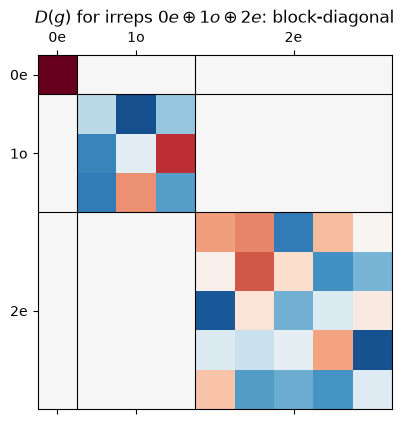

In [6]:
# Create a reducible representation as a direct sum of irreps: 0e + 1o + 2e
irreps = o3.Irreps("1x0e + 1x1o + 1x2e")
print(f"irreps = {irreps},  total dimension = {irreps.dim}")

# Create a random rotation matrix R and compute the block-diagonal representation D(g)
R = o3.rand_matrix()

# (9, 9) block-diagonal: D^0 (+) D^1 (+) D^2
D = irreps.D_from_matrix(R)

# Plot the block-diagonal structure of the reducible representation D(g)
fig, ax = plt.subplots(figsize=(4.6, 4.6))
ax.matshow(D, cmap="RdBu_r", vmin=-1, vmax=1)

for b in (1, 4):
    # block boundaries after dims 1 and 1+3
    ax.axhline(b - 0.5, color="k", lw=0.8); ax.axvline(b - 0.5, color="k", lw=0.8)
    
ax.set_xticks([0, 2, 6]); ax.set_xticklabels(["0e", "1o", "2e"])
ax.set_yticks([0, 2, 6]); ax.set_yticklabels(["0e", "1o", "2e"])
ax.set_title(r"$D(g)$ for irreps $0e \oplus 1o \oplus 2e$: block-diagonal")

blocks = [D[:1, :1], D[1:4, 1:4], D[4:, 4:]]
print("blocks match the individual Wigner matrices:",
      max((b - D_l(l, R)).abs().max().item() for l, b in enumerate(blocks)))

Everything outside the blocks is exactly zero. Under rotation, scalar components ($l=0$) never mix into vector components ($l=1$), and vectors never mix into $l=2$ components, and so on. An equivariant network is precisely a network whose features carry such a block structure and whose layers are constrained to respect it.

## Parity: from $SO(3)$ to $O(3)$

As we saw in [Lesson 01a](./01a_symmetry_and_equivariance.ipynb), $O(3) = SO(3) \times \{\mathbb{1}, P\}$. The inversion group, $\{ \mathbb{1}, P \}$, with only two elements has exactly two irreps: the **even** one, $D(P) = +1$, and the **odd** one, $D(P) = -1$. Since inversion, $P$, commutes with proper rotations, and $R$, every element of the $O(3)$'s subgroup, $SO(3)$, every irrep of $O(3)$ can be labeled by a pair $(l, p)$ with $p \in \{e, o\}$, acting as

$$ D^{(l,p)}(P\,R) = p \cdot D^{(l)}(R), \qquad \qquad p = \pm 1. $$

Both parities exist for every $l$ and physics provides examples of each case: a velocity vector is an **odd** vector (`1o`; it flips under inversion), while a cross product of two odd vectors, e.g. angular momentum $\vec{L} = \vec{r} \times \vec{p}$, is an **even** "pseudovector" (`1e`; it does *not* flip). In Lesson 02a, we return to these examples with a more detailed discussion. For now, let us just see how the inversion $P$ acts on each irrep of $O(3)$, i.e., the set of ($l, p$) irreps with $l = 0, 1, 2$ and both parities, $e$ and $o$.

In [7]:
# The inversion P = -1 (represented as a 3x3 matrix) acts on each irrep as +1 or
# -1 times identity:
P = -torch.eye(3)

for ir in ["0e", "0o", "1o", "1e", "2e", "2o"]:
    # Compute the representation matrix D^(ir)(P) for the inversion P
    d = o3.Irreps(ir).D_from_matrix(P)
    
    # The diagonal of D^(ir)(P) should be either all +1 or all -1, since P acts as a scalar on each irrep
    sign = d.diagonal().unique().item()
    
    # Print the result showing how the inversion acts on each irrep
    print(f"D^({ir})(P) = {sign:+.0f} * identity_{o3.Irreps(ir).dim}")

D^(0e)(P) = +1 * identity_1
D^(0o)(P) = -1 * identity_1
D^(1o)(P) = -1 * identity_3
D^(1e)(P) = +1 * identity_3
D^(2e)(P) = +1 * identity_5
D^(2o)(P) = -1 * identity_5


## The Cartesian 3-vector is the irrep $(l, p) = (1, -1)$ or `1o` in e3nn

A position or force vector, $\vec{v}$, rotates as $\vec{v} \mapsto R\vec{v}$ and flips under inversion, $\vec{v} \mapsto -\vec{v}$: that is exactly the $(l{=}1, p{=}{-}1)$ irrep.

In e3nn, the real basis of the $l=1$ irrep is aligned with the Cartesian axes so that the Wigner matrix *is* the rotation matrix:

$$ D^{(1o)}(R) = R, \qquad \text{and} \qquad D^{(1o)}(-R) = -R . $$

<div style="background: rgba(33, 150, 243, 0.10); border-left: 4px solid #2196f3; padding: 0.6em 1em; margin: 0.8em 0; border-radius: 0 4px 4px 0;">

<b>Note:</b> Beware that e3nn versions < 0.6 ordered the $l=1$ basis as $(y, z,
x)$, in which case $D^{(1)}$ equals $R$ only up to this permutation of
coordinates. In versions >= 0.6, the basis is aligned with $(x, y, z)$ and
$D^{(1)}$ matches $R$ directly. Always check your version's convention.
</div>

Let's verify this numerically by computing the Wigner D-matrix for $l=1$ and comparing it to the rotation matrix $R$.

In [8]:
# Create a random rotation matrix R
R = o3.rand_matrix()

# Check to see that the Wigner D-matrix for the 1o irrep matches the rotation
# matrix R (and -R for the roto-reflection)
for O, kind in [(R, "proper  "), (-R, "improper")]:
    D_1o = o3.Irreps("1o").D_from_matrix(O)
    print(f"{kind} (det O = {torch.det(O):+.0f}):  |D^(1o)(O) - O| = {(D_1o - O).abs().max():.2e}")

proper   (det O = +1):  |D^(1o)(O) - O| = 1.67e-15
improper (det O = -1):  |D^(1o)(O) - O| = 1.67e-15


Therefore, a Cartesian vector is indeed the `1o` irrep (in the e3nn 0.6 basis).

## Summary

In this lesson, we have learned:

- A **representation** maps group elements to matrices such that the mapping is homomorphic, i.e., $D(g_1 g_2) = D(g_1) D(g_2)$. We have verified this equality numerically for the vector and rank-2 tensor representations and for all Wigner D-matrices up to $l = 3$.
- For each $l = 0, 1, 2, \dots$, the **Irreps of $SO(3)$** have the dimension $2l+1$ and are represented by the unitary (in e3nn, real and orthogonal) Wigner D-matrices `o3.wigner_D(l, ...)`.
- Reducible representations decompose into direct sums. For example, a rank-2 tensor reduces into a direct sum of $1 + 3 + 5$ irreps corresponding to $l = 0, 1, 2$, respectively. These irreps never mix under the group operations. In e3nn, the `o3.Irreps("1x0e+1x1o+1x2e").D_from_matrix(g)` can build these matrices.
- **Schur orthogonality** states that the matrix elements of different irreps are orthogonal functions on the group. We have verified this by a Monte Carlo experiment using a normalized Haar measure.
- **Parity** doubles the number of labels: irreps of $O(3)$ are labeled by $(l, p)$ with $p = e/o$.
- A Cartesian 3-vector is `1o`, and in e3nn version $\ge 0.6$, $D^{(1o)}(R) = R$ exactly.

**Next:** In [Lesson 02a](02a_irreps_in_e3nn.ipynb), we discuss the `o3.Irreps` type system, multiplicities, feature layout, slicing, and test the equivariance of real feature tensors.

## Exercises

**1. Multiplicities.** Build `o3.Irreps("3x0e + 2x1o")` and use `plt.matshow` to visualize `D_from_matrix(R)` for a random rotation. How many blocks do you see, and why are the three $0e$ blocks and the two $1o$ blocks *identical copies* of each other?

<details><summary>Solution</summary>

```python
# Create an irreps object with multiplicities
ir = o3.Irreps("3x0e + 2x1o")

# Create a random rotation matrix
D = ir.D_from_matrix(o3.rand_matrix())

# Visualize the block-diagonal structure of the reducible representation
plt.matshow(D, cmap="RdBu_r", vmin=-1, vmax=1)
```

Five blocks: three $1\times 1$ blocks (each equal to 1 because scalars don't rotate) and two identical $3\times 3$ blocks, both equal to $D^{(1)}(R)$. Multiplicity means "the number of times the same irrep repeates". So, we expect every copy to transform with the *same* Wigner matrix, because the representation acts on each copy independently. (This is why, in Lesson 03, learnable weights will be allowed to mix their multiplicity channels but never their components within an irrep.) </details>

**2. Characters.** The trace $\chi^{(l)}(\theta) = \mathrm{Tr}\, D^{(l)}(R_\theta)$ of a rotation by angle $\theta$ (about any axis) is $\chi^{(l)}(\theta) = \sin\!\big((l + \tfrac12)\theta\big) / \sin(\theta/2)$. Verify this equation numerically for $l = 0, \dots, 3$ using `o3.wigner_D(l, theta, 0, 0)` (a rotation by $\theta$ about one axis). Why does not the trace depend on the chosen rotation axis?

<details><summary>Solution</summary>

```python
# Create a theta tensor and a zero tensor for the Euler angles
theta = torch.tensor(0.7)
zero  = torch.tensor(0.0)

# Compute the character for l = 0, 1, 2, 3 and compare 
# with the reference formula
for l in range(4):
    # Compute the character (trace of the Wigner D-matrix)
    chi = torch.trace(o3.wigner_D(l, theta, zero, zero))

    # Compute the reference character
    ref = torch.sin((l + 0.5) * theta) / torch.sin(theta / 2)
    print(l, f"{chi:.12f}", f"{ref:.12f}")
```

Any two rotations by the same angle are conjugate: $R_{\theta}' = Q R_\theta Q^{-1}$ for some rotation $Q$. Traces are invariant under conjugation, i.e., $\mathrm{Tr}\,D(Q)D(R_\theta)D(Q)^{-1} = \mathrm{Tr}\,D(R_\theta)$. Thus, the character depends only on $\theta$. </details>

**3. Pseudovectors ignore inversion.** Compute `o3.Irreps("1e").D_from_matrix(O)` for a random *improper* $O = -R$ and compare it with $D^{(1o)}(O)$. Which physical quantity transforms this way, and what does that imply for a network that predicts angular momentum from positions?

<details><summary>Solution</summary>

```python
# Create a random rotation matrix and its inversion
R = o3.rand_matrix()
O = -R

# zero: D^(1e)(-R) = D^(1)(R) = R
print(o3.Irreps("1e").D_from_matrix(O) - R)

# zero: D^(1o)(-R) = -R
print(o3.Irreps("1o").D_from_matrix(O) + R)
```

$D^{(1e)}(-R) = +D^{(1)}(R)$: the even vector (pseudovector) is blind to the inversion. Angular momentum $\vec{L} = \vec{r} \times \vec{p}$ is such a quantity. A network whose output is declared `1e` is *forced* to satisfy $\vec{L}(-x) = +\vec{L}(x)$, which is the correct physics. On the other hand, declaring the output quantity as `1o` would force the wrong sign. Choosing output irreps is a physics statement, not a formality. </details>

## References

- [Geiger & Smidt, *e3nn: Euclidean Neural Networks* arXiv.2207.09453 (2021)](https://arxiv.org/pdf/2207.09453)
- Schur orthogonality can be found in most group-theory text books (e.g. A. Zee, *Group Theory in a Nutshell for Physicists*).